Pixel-grafting
====

This notebook presents how to use the cleaned code for Pixel-grafting. See Section 6 of the Image Obfuscation for Privacy-Preserving Machine Learning report for more details.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
import util
import exp_models
import lambdas

We insert this code snippet to remove pseudorandomness. NN training results may still vary due to CUDA being enabled.

In [3]:
# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

We import our dataset and set our model

In [4]:
trainset, testset = util.get_sets("CIFAR100")
model_getter = exp_models.resnet18_100classes

Files already downloaded and verified
Files already downloaded and verified


We define the dataloaders and take a look at the dataloader:

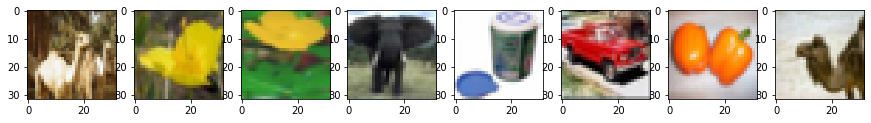

In [5]:
trainloader, N_BATCHES_TRAIN = util.get_loader(trainset, shuffle=True)
testloader, N_BATCHES_TEST = util.get_loader(testset, shuffle=False)
util.show_loader_cf(trainloader)

We will use util.pixelgraft_data instead of the standard mixup. Let's take a look at Pixel-grafting with a probability of $pr=0.9$. Note that Pixel-grafting was only implemented for probabilities vectors at $N=2$, although it can be generalized.

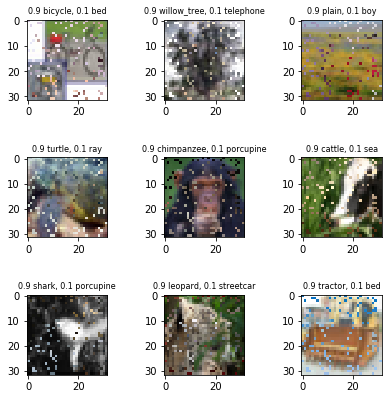

In [6]:
device = torch.device("cuda")

pr = np.array([0.9, 0.1])
for batch_id, (images, labels) in enumerate(trainloader):
    X_graft, ys, perms = util.pixelgraft_data(2, images.to(device), labels.to(device), pr, device)
    break
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
plt.tight_layout(pad=2)
for j in range(3):
    for i in range(3):
        util.show_np_arr(X_graft.cpu()[j*3+i], ax=axes[j, i])
        axes[j, i].set_title(
            str(pr[0])[:4] + " " + trainset.classes[ys[0][j*3+i]] + ", " +
            str(pr[1])[:4] + " " + trainset.classes[ys[1][j*3+i]],
            rotation=0, fontsize=8)

Now let's see what $pr=0.5$ looks like

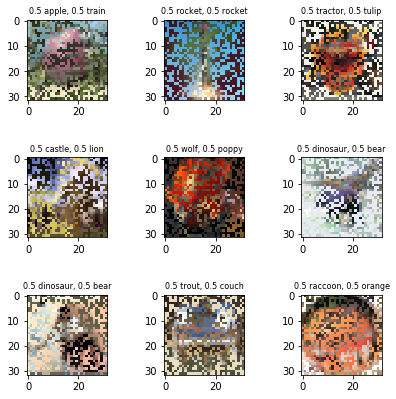

In [7]:
pr = np.array([0.5, 0.5])
for batch_id, (images, labels) in enumerate(trainloader):
    X_graft, ys, perms = util.pixelgraft_data(2, images.to(device), labels.to(device), pr, device)
    break
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
plt.tight_layout(pad=2)
for j in range(3):
    for i in range(3):
        util.show_np_arr(X_graft.cpu()[j*3+i], ax=axes[j, i])
        axes[j, i].set_title(
            str(pr[0])[:4] + " " + trainset.classes[ys[0][j*3+i]] + ", " +
            str(pr[1])[:4] + " " + trainset.classes[ys[1][j*3+i]],
            rotation=0, fontsize=8)

We load lambdas that will serve as probabilities. In the code, only the first weight $\lambda_0$ will be used to graft pixels, thus only $N=2$ is meaningful.

[0.75 0.25]


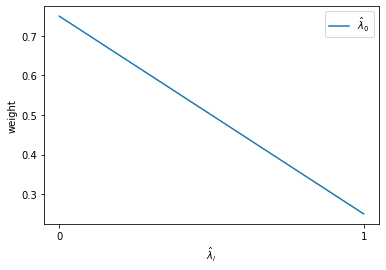

In [8]:
LAMBDAS = lambdas.sweetspot(2)
lambdas.show(LAMBDAS)

This is how we can run experiments. We will only perform 5 epochs/100 batches but a full experiment as in the report is 100 epochs/None batches, which is the default 500 batches. Note the additional argument *mixup_f* for Pixel-grafting.

In [9]:

RESULTS_FNAME = "deleteme0"
with open("results/"+RESULTS_FNAME, "w"):pass
test_accs, train_losses, val_losses, images_mx, ys, perms = util.perform_experiment(
    trainloader,
    testloader,
    lambdas=LAMBDAS,
    results_fname=RESULTS_FNAME,
    N_BATCHES_TRAIN=N_BATCHES_TRAIN,
    model_getter=model_getter,
    n_epochs=5,
    n_batches=100,
    mixup_f=util.pixelgraft_data
)


Saving results in deleteme0
Trying lambda= [0.75 0.25]
Performing n-mixup with N-mix: 2
Epoch[1/5]
train loss:4.7177 Epoch[1/5] Batch[0/500]
train loss:4.4458 Epoch[1/5] Batch[50/500]
train loss:4.2373 Epoch[1/5] Batch[100/500]
val loss:4.1298 Epoch[1/5]
val acc:9.0000 Epoch[1/5]
Epoch[2/5]
train loss:4.3846 Epoch[2/5] Batch[0/500]
train loss:4.1776 Epoch[2/5] Batch[50/500]
train loss:4.3197 Epoch[2/5] Batch[100/500]
val loss:3.9027 Epoch[2/5]
val acc:8.0000 Epoch[2/5]
Epoch[3/5]
train loss:4.0984 Epoch[3/5] Batch[0/500]
train loss:4.0673 Epoch[3/5] Batch[50/500]
train loss:4.1896 Epoch[3/5] Batch[100/500]
val loss:3.8630 Epoch[3/5]
val acc:13.0000 Epoch[3/5]
Epoch[4/5]
train loss:4.2114 Epoch[4/5] Batch[0/500]
train loss:3.8995 Epoch[4/5] Batch[50/500]
train loss:4.0146 Epoch[4/5] Batch[100/500]
val loss:3.6331 Epoch[4/5]
val acc:10.0000 Epoch[4/5]
Epoch[5/5]
train loss:3.8837 Epoch[5/5] Batch[0/500]
train loss:3.9272 Epoch[5/5] Batch[50/500]
train loss:4.0152 Epoch[5/5] Batch[100/500

We can see what the last batch of samples looked like through *images_mx*:

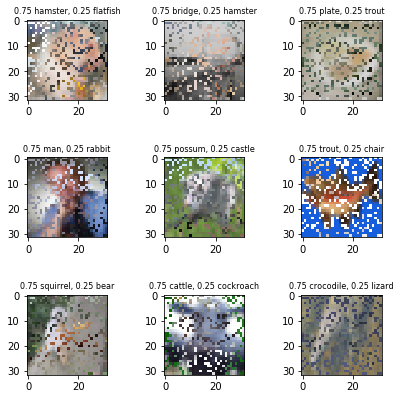

In [10]:

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
plt.tight_layout(pad=2)
for j in range(3):
    for i in range(3):
        util.show_np_arr(images_mx.cpu()[j*3+i], ax=axes[j, i])
        axes[j, i].set_title(
            str(LAMBDAS[0][0])[:4] + " " + trainset.classes[ys[0][j*3+i]] + ", " +
            str(LAMBDAS[0][1])[:4] + " " + trainset.classes[ys[1][j*3+i]],
            rotation=0, fontsize=8)
